In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cpi = pd.read_csv('../data/cpi.csv')

In [3]:
cpi

,year,month,cpi,type
0,2015,Jan,243.12,Food At Home
1,2015,Feb,242.91,Food At Home
2,2015,Mar,241.59,Food At Home
3,2015,Apr,241.31,Food At Home
4,2015,May,241.02,Food At Home
...,...,...,...,...
355,2024,Aug,243.87,Limited Service
356,2024,Sep,244.43,Limited Service
357,2024,Oct,244.94,Limited Service
358,2024,Nov,245.74,Limited Service


In [4]:
cpi_filtered = cpi[cpi['type'].isin(['Full Service', 'Limited Service'])]
cpi_filtered

,year,month,cpi,type
120,2015,Jan,157.60,Full Service
121,2015,Feb,157.89,Full Service
122,2015,Mar,158.13,Full Service
123,2015,Apr,158.52,Full Service
124,2015,May,158.71,Full Service
...,...,...,...,...
355,2024,Aug,243.87,Limited Service
356,2024,Sep,244.43,Limited Service
357,2024,Oct,244.94,Limited Service
358,2024,Nov,245.74,Limited Service


In [5]:
cpi_grouped = cpi_filtered.groupby(['year', 'type'])['cpi'].mean().reset_index()
cpi_grouped

,year,type,cpi
0,2015,Full Service,159.394167
1,2015,Limited Service,163.340833
2,2016,Full Service,163.125000
3,2016,Limited Service,167.718333
4,2017,Full Service,167.059167
5,2017,Limited Service,171.842500
6,2018,Full Service,170.981667
7,2018,Limited Service,176.580833
8,2019,Full Service,176.398333
9,2019,Limited Service,182.053333


In [6]:
cpi_pivoted = cpi_grouped.pivot(index='year', columns='type', values='cpi')
cpi_pivoted

type,Full Service,Limited Service
year,,
2015,159.394167,163.340833
2016,163.125000,167.718333
2017,167.059167,171.842500
2018,170.981667,176.580833
2019,176.398333,182.053333
2020,181.503333,189.915833
2021,189.681667,202.720000
2022,205.825833,217.394167
2023,218.353333,232.598333


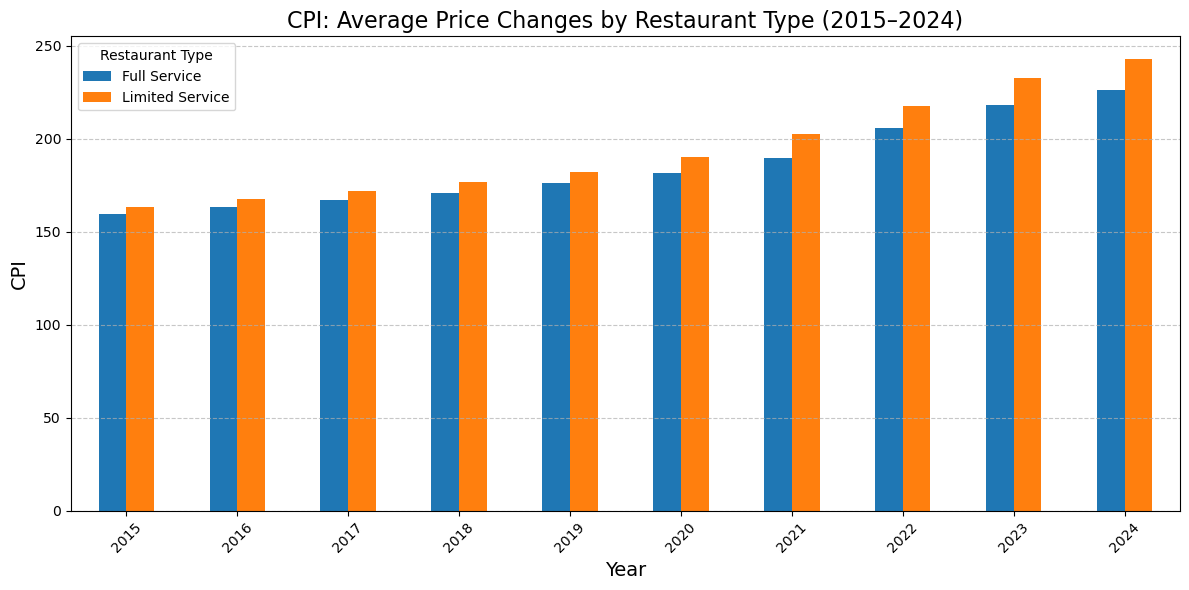

In [7]:
cpi_pivoted.plot(kind='bar', figsize=(12,6))

plt.title('CPI: Average Price Changes by Restaurant Type (2015–2024)', fontsize=16)
plt.ylabel('CPI', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Restaurant Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
peak_cpi = cpi.loc[cpi.groupby('type')['cpi'].idxmax()]
peak_cpi

,year,month,cpi,type
119,2024,Dec,308.38,Food At Home
239,2024,Dec,230.10,Full Service
359,2024,Dec,246.69,Limited Service


In [9]:
low_cpi = cpi.loc[cpi.groupby('type')['cpi'].idxmin()]
low_cpi

,year,month,cpi,type
23,2016,Dec,236.46,Food At Home
120,2015,Jan,157.60,Full Service
240,2015,Jan,161.49,Limited Service


In [10]:
cpi = pd.read_csv('../data/inflation_data.csv')
cpi.head()

,Year,FAH Inflation,FS Inflation,LS Inflation
0,2015,NaN,NaN,NaN
1,2016,-1.0,2.0,3.0
2,2017,0.0,2.0,2.0
3,2018,0.0,2.0,3.0
4,2019,1.0,3.0,3.0


In [11]:
cpi_sorted = cpi.sort_values('Year', ascending=False)
cpi_sorted.head(1)

,Year,FAH Inflation,FS Inflation,LS Inflation
9,2024,1.0,4.0,4.0


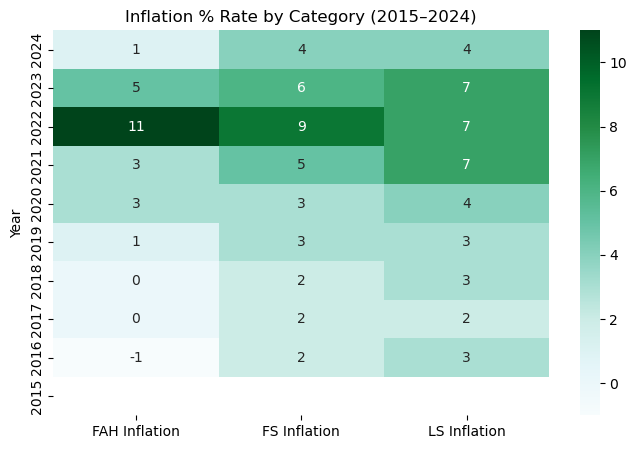

In [12]:
plt.figure(figsize=(8, 5))
sns.heatmap(cpi_sorted.set_index('Year'), annot=True, cmap='BuGn')
plt.title('Inflation % Rate by Category (2015–2024)')
plt.savefig('heatmap.png', dpi=300)
plt.show()

In [13]:
cpi = pd.read_csv('../data/inflation_data.csv')

In [14]:
cpi = cpi.dropna(subset=['FAH Inflation', 'FS Inflation', 'LS Inflation'])

In [15]:
cpi_sorted = cpi.sort_values('Year', ascending=True)

In [16]:
cpi_sorted.set_index('Year', inplace=True)

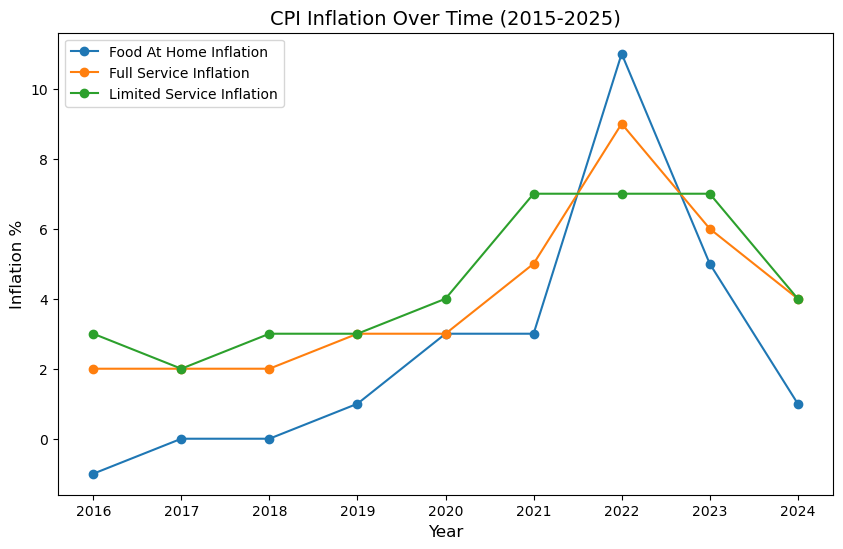

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(cpi_sorted.index, cpi_sorted['FAH Inflation'], label='Food At Home Inflation', marker='o')
plt.plot(cpi_sorted.index, cpi_sorted['FS Inflation'], label='Full Service Inflation', marker='o')
plt.plot(cpi_sorted.index, cpi_sorted['LS Inflation'], label='Limited Service Inflation', marker='o')

plt.title('CPI Inflation Over Time (2015-2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Inflation %', fontsize=12)
plt.legend()
plt.savefig('cpi_inflation_chart.png', dpi=300)
plt.show()

In [50]:
cpi_filtered = cpi[(cpi['Year'] >= 2015) & (cpi['Year'] <= 2024)]
cpi_filtered

,Year,FAH Inflation,FS Inflation,LS Inflation
1,2016,-1.0,2.0,3.0
2,2017,0.0,2.0,2.0
3,2018,0.0,2.0,3.0
4,2019,1.0,3.0,3.0
5,2020,3.0,3.0,4.0
6,2021,3.0,5.0,7.0
7,2022,11.0,9.0,7.0
8,2023,5.0,6.0,7.0
9,2024,1.0,4.0,4.0


In [54]:
total_inflation = {
    'Food at Home': cpi_filtered['FAH Inflation'].sum(),
    'Full Service': cpi_filtered['FS Inflation'].sum(),
    'Limited Service': cpi_filtered['LS Inflation'].sum()
}
total_inflation

{'Food at Home': 23.0, 'Full Service': 36.0, 'Limited Service': 40.0}

In [56]:
inflation_series = pd.Series(total_inflation)

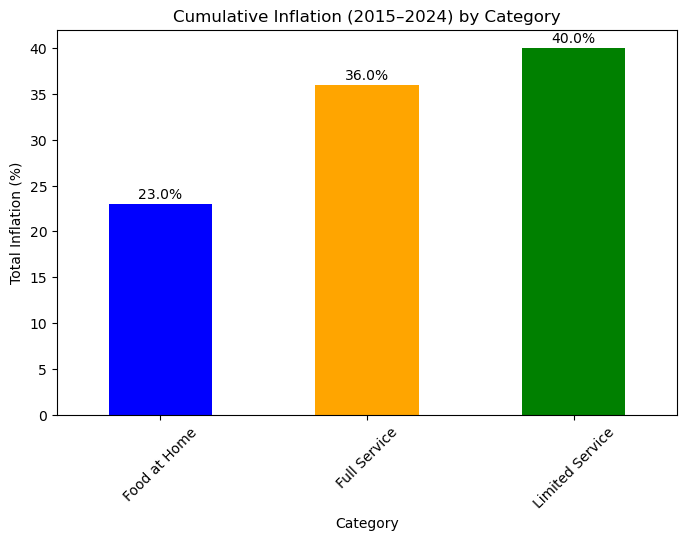

In [90]:
plt.figure(figsize=(8, 5))

inflation_series.sort_values().plot(kind='bar', 
                                    color=['blue', 'orange', 'green'])  

plt.title('Cumulative Inflation (2015–2024) by Category')
plt.ylabel('Total Inflation (%)')
plt.xlabel('Category')
plt.xticks(rotation=45)

for index, value in enumerate(inflation_series.sort_values()):
    plt.text(index, value + 0.3, f'{value:.1f}%', ha='center', va='bottom')
plt.savefig('cumulative_inflation_2015_2024.png', dpi=300)
plt.show()